# Analyse following simultaneously to find any pattern:  
1. Global order  
2. Local order  
3. Node communities
4. Club node according to communities
5. Calculate avg time of entry (from 20 node communities data)
6. Plot TOE (community wise)


In [32]:
%reload_ext autoreload
%autoreload 2
%matplotlib widget

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.ClusterTracking import SCTA
from tes.MBN_Res_Constrn import MBN_RC

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import pandas as pd
import numpy as np


#### Create objects


In [33]:
reader=DataRead()
analyse=AnalysisFunc()
mbn=MBN_RC()

..\..\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


#### Load data

In [34]:
df_itr=reader.data_read_bz2('itr20_fn.bz2')
df_loc = reader.data_read_bz2('l20_fn.bz2')

#### Running analysis to get itration for analysis

In [35]:
analyse.compute_param(df_itr,0.05)

Number of transitions / 100 iteration [1, 13]
Number of transition [0, 2, 3, 4, 6, 9, 10, 12, 13, 14, 19]
Number of transition with more than one transition [0, 2, 13, 19]


{'tran_per': [1, 13],
 'trans': [37.300000000000004,
  338.0,
  471.90000000000003,
  31.1,
  33.1,
  34.0,
  28.8,
  47.550000000000004,
  58.050000000000004,
  31.35,
  700.1,
  28.400000000000002,
  65.5],
 'sync': [198.85000000000002, 509.125, 278.3, 133.425]}

#### Checking by plotting above iterations to find suitable one

In [36]:
n=3
l=analyse.trans_state_time(analyse.smooth(df_itr[n]),0.05)

Plot for iteration to verify

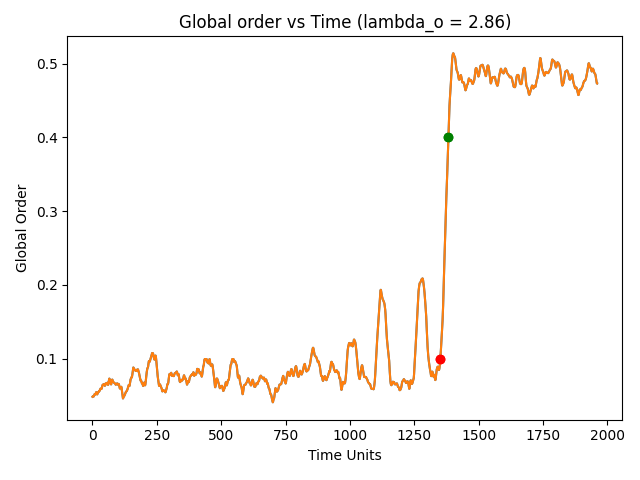

In [37]:
time = analyse.get_time(df_itr[n], 0.05)
plt.figure(num=1)
plt.plot(time, analyse.smooth(df_itr[n]))
plt.plot(l["low_cros"], [0.1] * len(l["low_cros"]), "ro")
plt.plot(l["up_cros"], [0.4] * len(l["up_cros"]), "go")
plt.xlabel("Time Units")
plt.ylabel("Global Order")
plt.title("Global order vs Time (lambda_o = 2.86)")
plt.tight_layout()
plt.show()

Therefore, we have choosen iteration 3 to move with further exploration

#### Load local order data for iteration 3


In [38]:
df_loc.loc[3].shape

(426, 5000)

#### Extract node communities data for iteration 3

Run SCTA for node communities

In [39]:
# df_dum=df_loc.loc[3].T
# local_order=df_dum.values
# scta = SCTA(mbn.binary_conn, 
#             local_order, 
#             local_order_phase = None, 
#             sync_thrsh=0.3)
# scta.track_clusters()
# scta.update_synchronization_cluster_stats()

Save node coomunities data as numpy array  
- SCTA threshold: 0.3 --- 'itr3_nc3.npy'
- SCTA threshold: 0.5 --- 'itr3_nc5.npy'

In [40]:
# np_path=Path('..\..\data')
# file=np_path / 'itr3_nc3.npy'
# np.save(file ,scta.node_communities)

#### Sort nodes as per mouse brain communities

Load communities data

In [41]:
l_communities = reader.data_read_pkl('connectivity_matrix/mb_communities_dict.pickle')

Assigning names to communities 

In [42]:
community_names = {
    0:'MO', 1:'MID', 2:'VIS', 3:'ORB', 4:'HTh', 5:'HIND', 6:'OLF', 7:'HIPP'
}

communities = {
    community_names[i]:v for i, v in l_communities.items()
}

{k:len(v) for k,v in communities.items()}

{'MO': 56,
 'VIS': 50,
 'ORB': 34,
 'HTh': 44,
 'OLF': 36,
 'HIPP': 50,
 'MID': 70,
 'HIND': 86}

In [43]:
community_map = pd.concat([pd.Series(data=k, index=v) for k, v in communities.items()])

In [44]:
community_map.index

Int64Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
            ...
            416, 417, 418, 419, 420, 421, 422, 423, 424, 425],
           dtype='int64', length=426)

In [45]:
type(community_map.index)                 

pandas.core.indexes.numeric.Int64Index

In [46]:
fn_sync_order = ['HIND', 'MID', 'HIPP', 'VIS', 'MO', 'HTh', 'ORB', 'OLF']
sort_order = {
    fn_sync_order[i]:i for i in range(len(fn_sync_order))
}

#### Analysis on node communities data

In [47]:
nc5 = np.load('..\..\data\itr3_nc5.npy')
nc3 = np.load('..\..\data\itr3_nc3.npy')

In [48]:
nc3_unique, nc3_count = np.unique(nc3,return_counts=True)

nc5_unique, nc5_count = np.unique(nc5,return_counts=True)

In [49]:
np.argsort(nc3_count)[::-1]

array([  0,  99,  42,  89,  60,  27,  51,   4,  20,  10,  71,  73,  29,
        44,  61,  46,   6,  45,  54,  43,  57,  41,  83,  63,  12,  62,
        65,  59,  48,  55,  47,  49,  38,  53,  11,  28,  64,  52,   2,
        34,  13,  50,  18,  67,  66,  30,  95,   9,  77,  56,  68,  90,
        31,  36,  96,  32,  58,  22,  33,  26,  14,  21,  15,  35, 100,
        69,  16,  74,  23,  17,   1,  70,  19,   5,  91,  75,  39,  72,
        80,  37,  24,  98,  92,  78,  76,   7,  93,  40,  94, 101,  97,
        25,   8,  79, 102, 104, 103,  81,  84,  82,  85,  86, 105,  87,
       106,  88, 111, 113, 107,   3, 112, 108, 114, 115, 116, 109, 117,
       110, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127], dtype=int64)

In [50]:
np.argsort(nc5_count)[::-1]

array([ 0,  3,  1,  2,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int64)

Notice how less cluster forms for SCTA threshold 0.5

Finding main cluster

In [51]:
nc3_main_cluster = np.argsort(nc3_count)[::-1][1]
nc3_main_cluster

99

In [52]:
nc5_main_cluster = np.argsort(nc5_count)[::-1][1]
nc5_main_cluster

3

Modulating nc data for nice heatmaps

In [53]:
nc5.shape

(5000, 426)

In [54]:
# making 0 values as nan
nc5[nc5==0]=np.nan
nc3[nc3==0]=np.nan



In [55]:
# make nc nodes arrange in order of communities
def arrange_nodes(nc):
    desired_order=list(community_map.index)
    arranged_nc = nc[:, desired_order]
    return arranged_nc

arranged_nc=arrange_nodes(nc5) 

In [56]:
#compute toe for given nc
toe=analyse.compute_toe(arranged_nc,nc5_main_cluster)
toe_df=pd.DataFrame(toe)
toe_df.rename(columns={0:'toe'},inplace=True)
community_map.rename('community',inplace=True)
df_map=pd.concat([community_map,toe_df],axis=1)

In [57]:
df_map

,community,toe
0,MO,3509.0
1,MO,3599.0
2,MO,3569.0
3,MO,3603.0
4,MO,3600.0
...,...,...
421,HIND,330.0
422,HIND,3122.0
423,HIND,NaN
424,HIND,4271.0


In [58]:
df_map = df_map.groupby(['community'],sort=False).apply(lambda s:s.sort_values(by='toe'))

In [59]:
df_map

community     toe
community                      
MO        213        MO   483.0
          223        MO   707.0
          89         MO   752.0
          88         MO  1007.0
          249        MO  1007.0
...                 ...     ...
HIND      414      HIND     NaN
          416      HIND     NaN
          417      HIND     NaN
          420      HIND     NaN
          423      HIND     NaN

[426 rows x 2 columns]

In [60]:
df_map=df_map.droplevel('community')

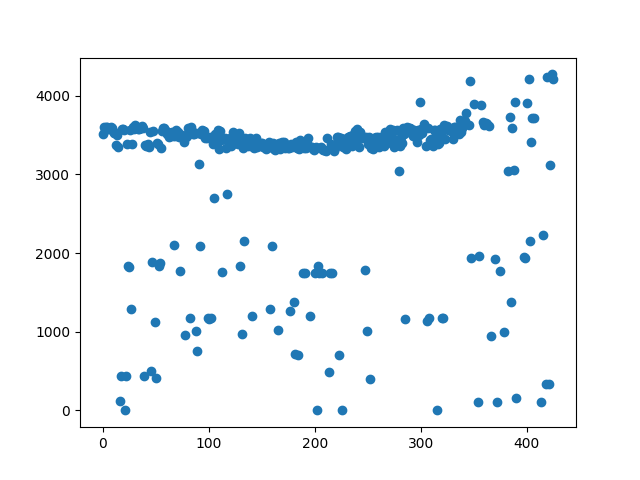

In [61]:
plt.figure(clear=True)
plt.scatter(list(df_map.index),df_map['toe'])
plt.show()

#### Transition from global order data

In [64]:
df_smooth=np.array(analyse.smooth(df_itr[3]))
# finding where it cross 0.3
# notice use nd array as this you used for local order data collection
cross=np.where(df_smooth >= 0.3)[0][0]
time_steps = list(range(0, df_smooth.shape[0]))

#### Creating plots for comapring SCTA thresholds 0.3 and 0.5

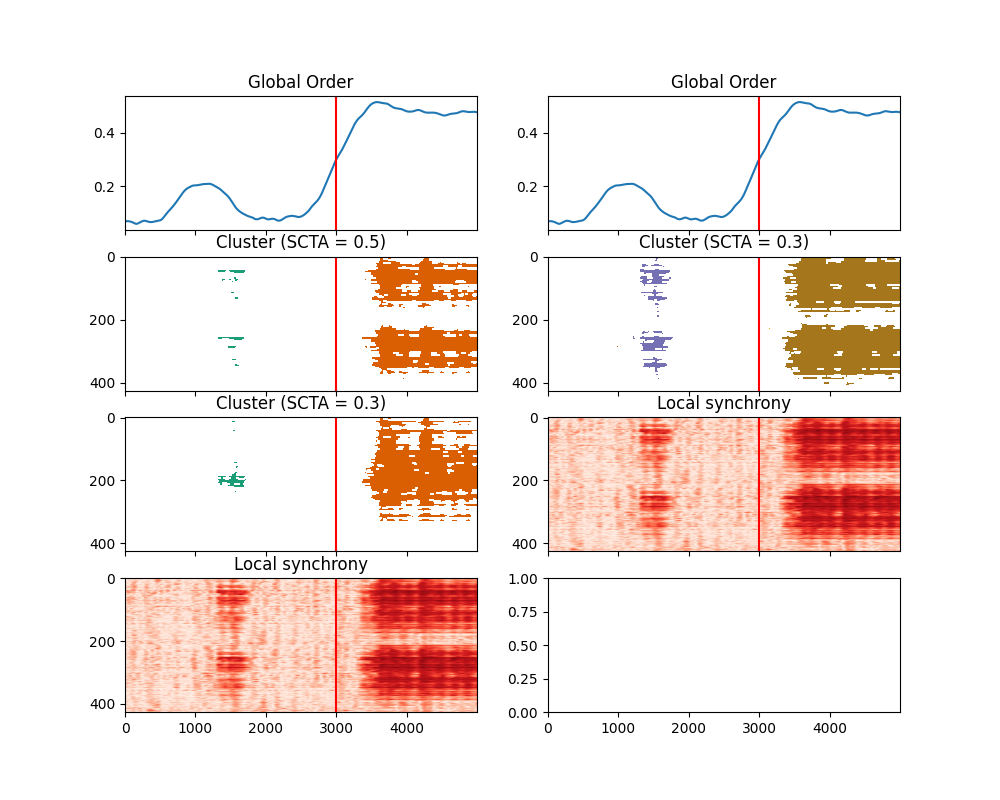

In [65]:
fig, ax = plt.subplots(4,2,figsize=(10,8),sharex=True)
#1st column for SCTA 0.3 and 2nd for SCTA 0.5

# Plot transition
ax[0,0].plot(list(range(0,5000)),df_smooth[cross-3000:cross+2000])
ax[0,0].set_title('Global Order')
ax[0,0].axvline(3000,color='r')
# xtick=[cross-3000,cross-2000,cross-1000,cross,cross+1000,cross+2000]
# ax[0,0].set_xticks(xtick) 
# ax[0,0].set_xticklabels([])

#plot node communities SCTA=0.5
ax[1,0].imshow(nc5.T,cmap='Dark2',aspect='auto')
ax[1,0].axvline(3000,color='r')
ax[1,0].set_title('Cluster (SCTA = 0.5)')

#plot node communities SCTA=0.3
ax[2,0].imshow(arranged_nc.T,cmap='Dark2',aspect='auto')
ax[2,0].axvline(3000,color='r')
ax[2,0].set_title('Cluster (SCTA = 0.3)')

#plot local order
ax[3,0].imshow(df_loc.loc[n].values,cmap='Reds',aspect='auto')
ax[3,0].axvline(3000,color='r')
ax[3,0].set_title('Local synchrony')




# Plot transition
ax[0,1].plot(list(range(0,5000)),df_smooth[cross-3000:cross+2000])
ax[0,1].set_title('Global Order')
ax[0,1].axvline(3000,color='r')
# xtick=[cross-3000,cross-2000,cross-1000,cross,cross+1000,cross+2000]
# ax[0,0].set_xticks(xtick) 
# ax[0,0].set_xticklabels([])

#plot node communities
ax[1,1].imshow(nc3.T,cmap='Dark2',aspect='auto')
ax[1,1].axvline(3000,color='r')
ax[1,1].set_title('Cluster (SCTA = 0.3)')

#plot local order
ax[2,1].imshow(df_loc.loc[n].values,cmap='Reds',aspect='auto')
ax[2,1].axvline(3000,color='r')
ax[2,1].set_title('Local synchrony')


fig.subplots_adjust(wspace=0.2, hspace=0.2)

